Dataset Shape: (1117, 30)
Cleaned Data Shape: (330, 5)

Dataset Summary:
       pricing/rate/amount  numberOfGuests       stars  isHostedBySuperhost
count           330.000000      330.000000  330.000000                330.0
mean             40.154545        3.881818    4.668091                  1.0
std              16.861055        2.273403    0.388735                  0.0
min              11.000000        1.000000    2.330000                  1.0
25%              26.000000        2.000000    4.562500                  1.0
50%              40.000000        3.000000    4.770000                  1.0
75%              50.000000        4.000000    4.920000                  1.0
max              80.000000       16.000000    5.000000                  1.0


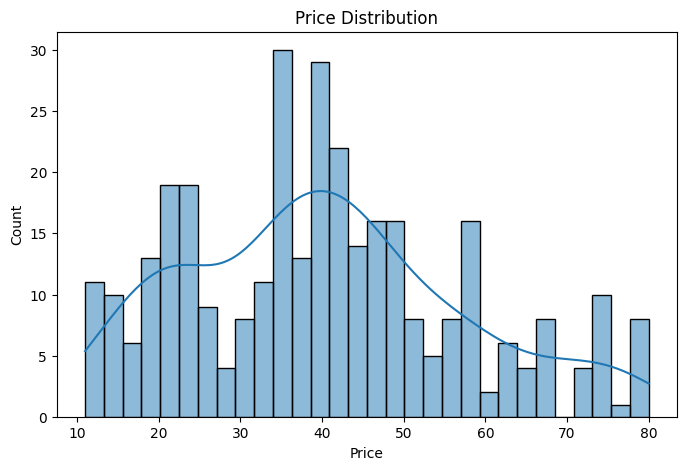

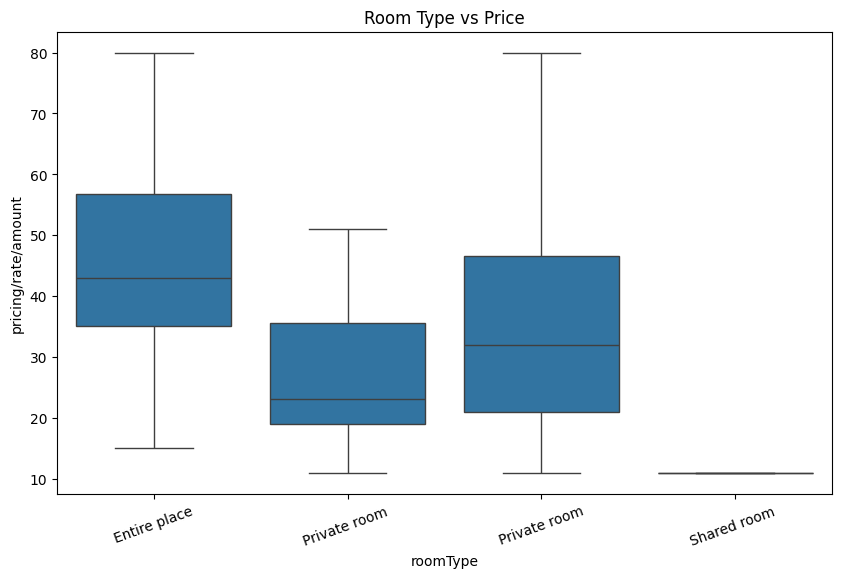

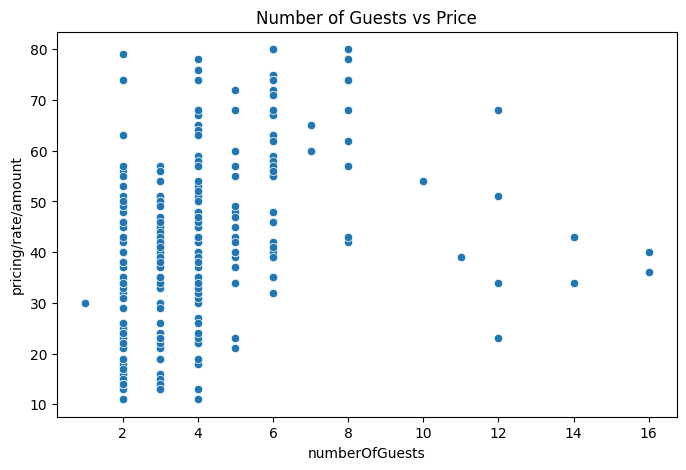

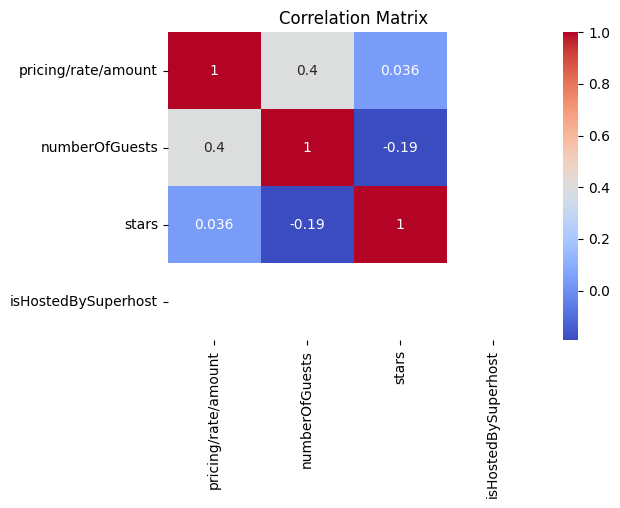


Training Samples: 264
Testing Samples: 66

===== MODEL PERFORMANCE =====
MSE  : 209.07
RMSE : 14.46
R²   : 0.206


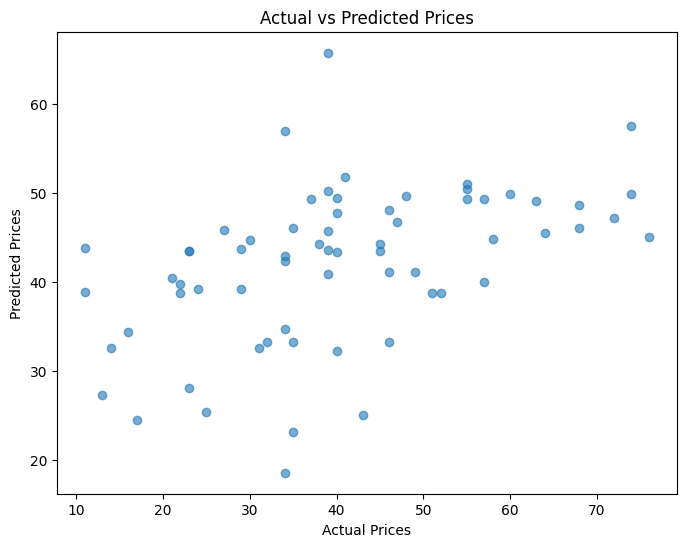

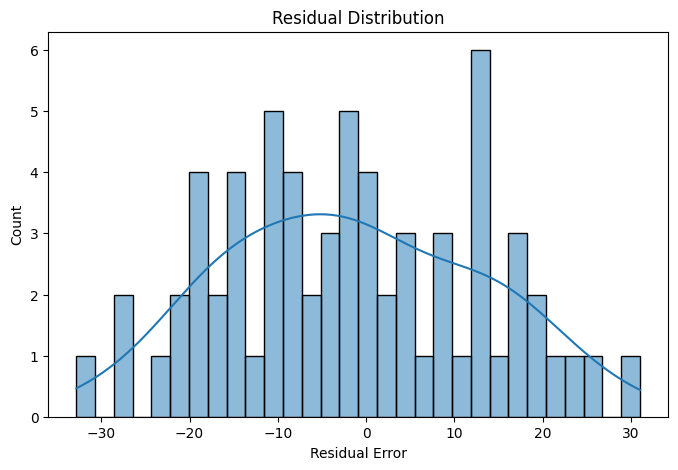


Project Completed Successfully!


In [ ]:
# =====================================================
# Airbnb Pakistan Price Prediction using Machine Learning
# =====================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_excel("/content/Combined .xlsx")

print("Dataset Shape:", df.shape)

# =====================================================
# Select Useful Columns
# =====================================================

data = df[
    [
        'pricing/rate/amount',
        'roomType',
        'numberOfGuests',
        'stars',
        'isHostedBySuperhost'
    ]
].copy()

# =====================================================
# Data Cleaning
# =====================================================

# Convert price to numeric
data['pricing/rate/amount'] = pd.to_numeric(
    data['pricing/rate/amount'],
    errors='coerce'
)

# Convert stars to numeric
data['stars'] = pd.to_numeric(
    data['stars'],
    errors='coerce'
)

# Remove missing values
data.dropna(inplace=True)

# Convert Boolean to Integer
data['isHostedBySuperhost'] = (
    data['isHostedBySuperhost']
    .astype(bool)
    .astype(int)
)

# Remove Extreme Outliers
Q1 = data['pricing/rate/amount'].quantile(0.25)
Q3 = data['pricing/rate/amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[
    (data['pricing/rate/amount'] >= lower_bound) &
    (data['pricing/rate/amount'] <= upper_bound)
]

print("Cleaned Data Shape:", data.shape)

# =====================================================
# Exploratory Data Analysis
# =====================================================

print("\nDataset Summary:")
print(data.describe())

# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    data['pricing/rate/amount'],
    bins=30,
    kde=True
)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

# Room Type vs Price
plt.figure(figsize=(10,6))
sns.boxplot(
    x='roomType',
    y='pricing/rate/amount',
    data=data
)
plt.title("Room Type vs Price")
plt.xticks(rotation=20)
plt.show()

# Guests vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='numberOfGuests',
    y='pricing/rate/amount',
    data=data
)
plt.title("Number of Guests vs Price")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    data[['pricing/rate/amount',
          'numberOfGuests',
          'stars',
          'isHostedBySuperhost']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

# =====================================================
# Feature Engineering
# =====================================================

room_encoded = pd.get_dummies(
    data['roomType'],
    prefix='Room',
    drop_first=True
)

X = pd.concat([
    data[['numberOfGuests',
          'stars',
          'isHostedBySuperhost']],
    room_encoded
], axis=1)

# Convert all columns to numeric
X = X.astype(float)

y = data['pricing/rate/amount']

# =====================================================
# Train-Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# =====================================================
# Linear Regression Model
# =====================================================

model = LinearRegression()

model.fit(X_train, y_train)

# =====================================================
# Predictions
# =====================================================

predictions = model.predict(X_test)

# =====================================================
# Model Evaluation
# =====================================================

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\n===== MODEL PERFORMANCE =====")
print("MSE  :", round(mse,2))
print("RMSE :", round(rmse,2))
print("R²   :", round(r2,4))

# =====================================================
# Actual vs Predicted Plot
# =====================================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.6)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

# =====================================================
# Residual Analysis
# =====================================================

residuals = y_test - predictions

plt.figure(figsize=(8,5))
sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Residual Error")

plt.show()

print("\nProject Completed Successfully!")